# FIFA World Cup — Experimentation & Causal Analytics

Three experiments on open World Cup data:
1. **VAR causal impact** — interrupted time-series + match-level Poisson GLM
2. **Shootout first-kicker advantage** — natural experiment + power analysis
3. **32-team vs 48-team format** — designed A/B test via Monte Carlo

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd, numpy as np
from data_loader import download, tournament_rates
download()
tournament_rates(mens_only=True)[
    ['tournament_name','year','matches','penalty_rate','post_var']].tail(8)

,tournament_name,year,matches,penalty_rate,post_var
14,1994 FIFA Men's World Cup,1994,52,0.288462,0
15,1998 FIFA Men's World Cup,1998,64,0.265625,0
16,2002 FIFA Men's World Cup,2002,64,0.203125,0
17,2006 FIFA Men's World Cup,2006,64,0.203125,0
18,2010 FIFA Men's World Cup,2010,64,0.140625,0
19,2014 FIFA Men's World Cup,2014,64,0.187500,0
20,2018 FIFA Men's World Cup,2018,64,0.343750,1
21,2022 FIFA Men's World Cup,2022,64,0.265625,1


## Module 1 — Did VAR change penalty rates?

In [2]:
from module1_var import fit_match_level, fit_its
ml = fit_match_level()
print(f"Match-level IRR: {ml['irr']:.2f}x (95% CI {ml['irr_ci'][0]:.2f}-{ml['irr_ci'][1]:.2f}), p={ml['p_value']:.4f}")
its = fit_its('penalty_rate')
print(f"Tournament-level: p={its['p_value']:.3f} (underpowered)")

Match-level IRR: 2.16x (95% CI 1.17-3.98), p=0.0138
Tournament-level: p=0.212 (underpowered)


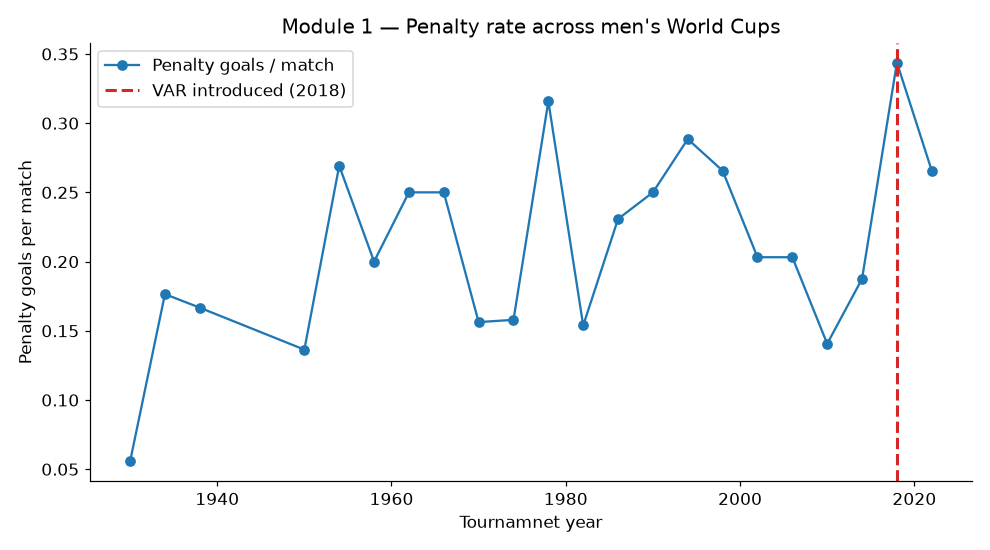

In [3]:
from viz import fig_var
from IPython.display import Image
Image(fig_var())

## Module 2 — Does kicking first win the shootout?

In [4]:
from module2_shootout import run_test
r = run_test()
print(f"First kicker won {r['win_rate']*100:.1f}% (n={r['n_shootouts']}), p={r['p_value']:.3f}")

First kicker won 60.5% (n=43), p=0.222


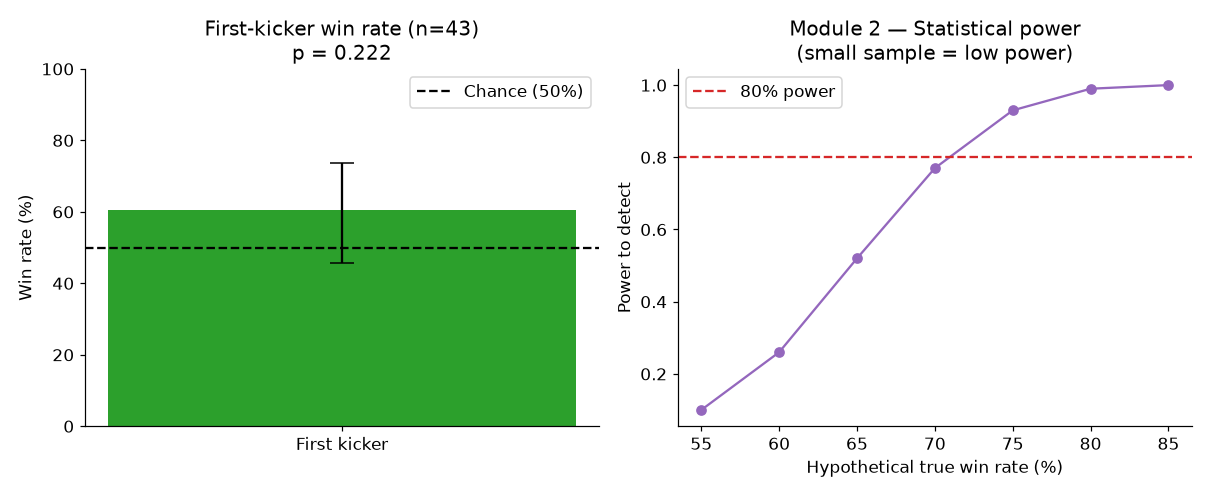

In [5]:
from viz import fig_shootout
Image(fig_shootout())

## Module 3 — 32-team vs 48-team A/B test

In [6]:
from elo import compute_ratings
compute_ratings().head(8).round(0)

Netherlands     1741.0
France          1724.0
Brazil          1693.0
Germany         1683.0
West Germany    1681.0
Argentina       1679.0
Italy           1616.0
Belgium         1607.0
dtype: float64

In [7]:
from module3_format_ab import run_experiment, power_n
print(f'Power analysis: {power_n()} sims/arm; using floor of 1000.')
exp = run_experiment()
labels = {'champion_elo':'Champion Elo','top4_seed_won':'Top-4 seed won',
          'knockout_upsets':'Knockout upsets','champion_seed_rank':'Champion rank'}
pd.DataFrame([{'Metric':labels[k],'32-team':round(v['mean_A_32team'],3),
  '48-team':round(v['mean_B_48team'],3),"Cohen's d":round(v['cohens_d'],2),
  'p':round(v['p_value'],4),'Sig':'Yes' if v['significant'] else 'no'}
  for k,v in exp['results'].items()])

Power analysis: 394 sims/arm; using floor of 1000.


,Metric,32-team,48-team,Cohen's d,p,Sig
0,Champion Elo,1589.005,1569.868,-0.19,0.0,Yes
1,Top-4 seed won,0.463,0.318,-0.30,0.0,Yes
2,Knockout upsets,6.645,14.456,3.30,0.0,Yes
3,Champion rank,7.193,13.714,0.61,0.0,Yes


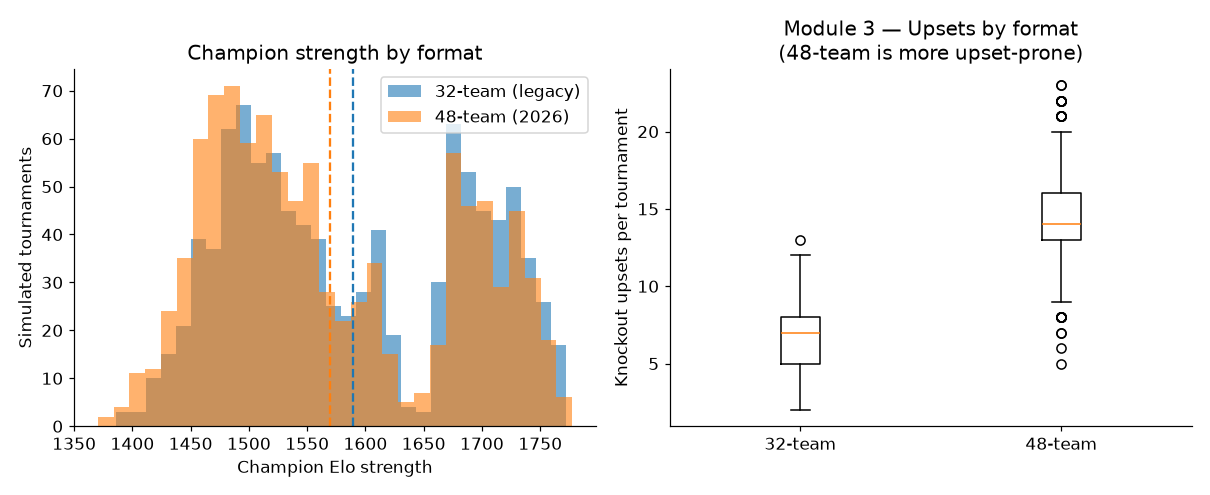

In [8]:
from viz import fig_format
Image(fig_format(exp))